# **Revenue Manager's Analysis**

## Objectives

* Review year-on-year cancellation distribution to ensure integrity of the dataset and determine the date-shift
* Adjust the dates on the dataset to give a more realistic timeframe to the data
* Create an RM dataset with engineered columns for arrival date, arrival day, cancellation lead-time and LOS
* Explore the dataset from a Revenue Manager's perspective to inform business understanding
* Generate early correlations and conclusions to inform hypotheses

## Inputs

* outputs/datasets/collection/HotelBookings.csv

## Outputs

* outputs/datasets/rm_analysis/HotelBookingsPrepared.csv - The raw dataset with the dates time-shifted to a more recent timeline

## Additional Comments

* This is a supplementary notebook drawing on professional experience to inform business requirements and understanding
* Alterations made to the dataset in preparing the RM dataset are limited to this notebook, formal cleaning and engineering decisions will be made in the data cleaning notebook
* Findings from this notebook inform but do not pre-determine the EDA, the full dataset will be used for correlation analysis to allow the data to speak for itself without undue bias


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))

current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect'

## Data Preparation 

**Imports**

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Load Dataframe**

In [4]:
df = pd.read_csv("outputs/datasets/collection/HotelBookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


---

* Examine cancellation distribution for each year of data

<Axes: xlabel='arrival_date_year', ylabel='count'>

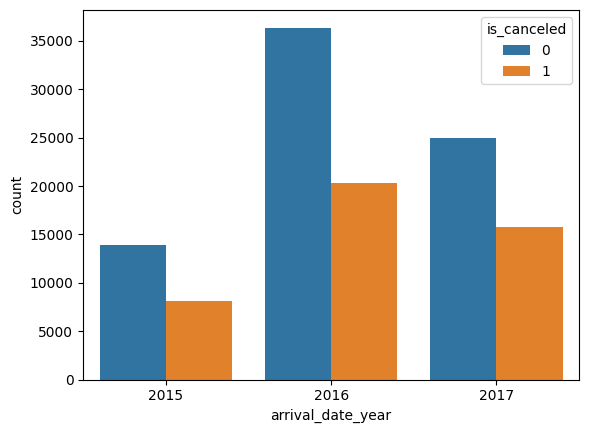

In [5]:
sns.countplot(data=df,
              x="arrival_date_year",
              hue="is_canceled")

* Although the cancellation rate seems balanced across the 3 years, the number of bookings is not. To preserve the integrity of the data, a simple renaming of the years is the most appropriate date shift.
* Dates to be replaced with 2023, 2024 and 2025

In [6]:
df_updated_dates = df.replace(to_replace={
    2015: 2023,
    2016: 2024,
    2017: 2025
})

df_updated_dates["reservation_status_date"] = (
    df_updated_dates["reservation_status_date"]
    .str.replace('2015', '2023')
    .str.replace('2016', '2024')
    .str.replace('2017', '2025')
)

df_updated_dates.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
1,Resort Hotel,0,737,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
2,Resort Hotel,0,7,2023,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02
3,Resort Hotel,0,13,2023,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02
4,Resort Hotel,0,14,2023,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2023-07-03


## Revenue Manager Dataset

* Create columns for:
    * Arrival Date
    * Arrival Day
    * Cancellation Lead Time 
    * Length of Stay

In [7]:
rm_df = df_updated_dates.copy(deep=True)
rm_df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
1,Resort Hotel,0,737,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
2,Resort Hotel,0,7,2023,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02


---

In [8]:
import calendar
month_map = {name: num for num, name in enumerate(calendar.month_name) if name}

rm_df["arrival_date_month"] = rm_df["arrival_date_month"].map(month_map)

rm_df["arrival_date"] = pd.to_datetime({
    "year": rm_df["arrival_date_year"],
    "month": rm_df["arrival_date_month"],
    "day": rm_df["arrival_date_day_of_month"]}, format="")
rm_df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,0,342,2023,7,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01,2023-07-01
1,Resort Hotel,0,737,2023,7,27,1,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01,2023-07-01
2,Resort Hotel,0,7,2023,7,27,1,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02,2023-07-01


* Remove remaining date columns

In [9]:
rm_df = rm_df.drop(columns=[
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month"])
rm_df.head(3)

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,0,342,0,0,2,0.0,0,BB,PRT,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01,2023-07-01
1,Resort Hotel,0,737,0,0,2,0.0,0,BB,PRT,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01,2023-07-01
2,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02,2023-07-01


* Generate LOS column

In [10]:
rm_df["los"] = rm_df["stays_in_weekend_nights"] + rm_df["stays_in_week_nights"]
rm_df.head(3)

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,los
0,Resort Hotel,0,342,0,0,2,0.0,0,BB,PRT,...,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01,2023-07-01,0
1,Resort Hotel,0,737,0,0,2,0.0,0,BB,PRT,...,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01,2023-07-01,0
2,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02,2023-07-01,1


* Calculate cancellation lead time

In [11]:
rm_df["cxl_lead_time"] = np.where(
    rm_df["is_canceled"] == 1,
    rm_df["arrival_date"] - pd.to_datetime(rm_df["reservation_status_date"]),
    None
)
rm_df.head(10)

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,los,cxl_lead_time
0,Resort Hotel,0,342,0,0,2,0.0,0,BB,PRT,...,0,Transient,0.0,0,0,Check-Out,2023-07-01,2023-07-01,0,None
1,Resort Hotel,0,737,0,0,2,0.0,0,BB,PRT,...,0,Transient,0.0,0,0,Check-Out,2023-07-01,2023-07-01,0,None
2,Resort Hotel,0,7,0,1,1,0.0,0,BB,GBR,...,0,Transient,75.0,0,0,Check-Out,2023-07-02,2023-07-01,1,None
3,Resort Hotel,0,13,0,1,1,0.0,0,BB,GBR,...,0,Transient,75.0,0,0,Check-Out,2023-07-02,2023-07-01,1,None
4,Resort Hotel,0,14,0,2,2,0.0,0,BB,GBR,...,0,Transient,98.0,0,1,Check-Out,2023-07-03,2023-07-01,2,None
5,Resort Hotel,0,14,0,2,2,0.0,0,BB,GBR,...,0,Transient,98.0,0,1,Check-Out,2023-07-03,2023-07-01,2,None
6,Resort Hotel,0,0,0,2,2,0.0,0,BB,PRT,...,0,Transient,107.0,0,0,Check-Out,2023-07-03,2023-07-01,2,None
7,Resort Hotel,0,9,0,2,2,0.0,0,FB,PRT,...,0,Transient,103.0,0,1,Check-Out,2023-07-03,2023-07-01,2,None
8,Resort Hotel,1,85,0,3,2,0.0,0,BB,PRT,...,0,Transient,82.0,0,1,Canceled,2023-05-06,2023-07-01,3,4838400000000000
9,Resort Hotel,1,75,0,3,2,0.0,0,HB,PRT,...,0,Transient,105.5,0,0,Canceled,2023-04-22,2023-07-01,3,6048000000000000


* Rearrange columns

In [12]:
rm_df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date',
 'arrival_date',
 'los',
 'cxl_lead_time']

In [13]:
rm_df = rm_df[['hotel',
               'arrival_date',
               'lead_time',
               'los',
               'adr',
               'stays_in_weekend_nights',
               'stays_in_week_nights',
               'is_canceled',
               'cxl_lead_time',
               'adults',
               'children',
               'babies',
               'meal',
               'deposit_type',
               'country',
               'customer_type',
               'market_segment',
               'distribution_channel',
               'agent',
               'company',
               'is_repeated_guest',
               'previous_cancellations',
               'previous_bookings_not_canceled',
               'reserved_room_type',
               'assigned_room_type',
               'booking_changes',
               'days_in_waiting_list',
               'required_car_parking_spaces',
               'total_of_special_requests',
               'reservation_status',
               'reservation_status_date', 
 ]]
rm_df.head(3)

,hotel,arrival_date,lead_time,los,adr,stays_in_weekend_nights,stays_in_week_nights,is_canceled,cxl_lead_time,adults,...,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,2023-07-01,342,0,0.0,0,0,0,None,2,...,0,0,C,C,3,0,0,0,Check-Out,2023-07-01
1,Resort Hotel,2023-07-01,737,0,0.0,0,0,0,None,2,...,0,0,C,C,4,0,0,0,Check-Out,2023-07-01
2,Resort Hotel,2023-07-01,7,1,75.0,0,1,0,None,1,...,0,0,A,C,0,0,0,0,Check-Out,2023-07-02


* Remove unnecessary columns

In [14]:
rm_df = rm_df.drop(columns=[
    "reservation_status", 
    "reservation_status_date", 
    "assigned_room_type", 
    "required_car_parking_spaces"])
rm_df.head(3)

,hotel,arrival_date,lead_time,los,adr,stays_in_weekend_nights,stays_in_week_nights,is_canceled,cxl_lead_time,adults,...,distribution_channel,agent,company,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,days_in_waiting_list,total_of_special_requests
0,Resort Hotel,2023-07-01,342,0,0.0,0,0,0,None,2,...,Direct,NaN,NaN,0,0,0,C,3,0,0
1,Resort Hotel,2023-07-01,737,0,0.0,0,0,0,None,2,...,Direct,NaN,NaN,0,0,0,C,4,0,0
2,Resort Hotel,2023-07-01,7,1,75.0,0,1,0,None,1,...,Direct,NaN,NaN,0,0,0,A,0,0,0


* Add total cost column

In [15]:
rm_df["total_cost"] = rm_df["los"] * rm_df["adr"]
rm_df.head(3)

,hotel,arrival_date,lead_time,los,adr,stays_in_weekend_nights,stays_in_week_nights,is_canceled,cxl_lead_time,adults,...,agent,company,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,days_in_waiting_list,total_of_special_requests,total_cost
0,Resort Hotel,2023-07-01,342,0,0.0,0,0,0,None,2,...,NaN,NaN,0,0,0,C,3,0,0,0.0
1,Resort Hotel,2023-07-01,737,0,0.0,0,0,0,None,2,...,NaN,NaN,0,0,0,C,4,0,0,0.0
2,Resort Hotel,2023-07-01,7,1,75.0,0,1,0,None,1,...,NaN,NaN,0,0,0,A,0,0,0,75.0


## Analysis of RM Dataset

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In case you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [17]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (2852421808.py, line 5)